<a href="https://colab.research.google.com/github/ambatiharshitha/i2o-Retail-assignment-/blob/main/Amazon_review_sentimental_analysis(I2O).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#installing kaggle library
!pip install kaggle

In [2]:
 #configuring the path of Kaggle.json file
 !mkdir -p ~/.kaggle
 !cp kaggle.json ~/.kaggle/
 !chmod 600 ~/.kaggle/kaggle.json

In [3]:
#API to fetch the dataset from kaggle
!kaggle datasets download -d shivamparab/amazon-electronics-reviews


Dataset URL: https://www.kaggle.com/datasets/shivamparab/amazon-electronics-reviews
License(s): copyright-authors


In [10]:
#extracting the compressed file

from zipfile import ZipFile
dataset = '/content/amazon-electronics-reviews.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [12]:
import pandas as pd
import json

# Path to the JSON file in the Kaggle dataset
json_path = '/content/Electronics_5.json'

# Load the line-delimited JSON file
data = []
with open(json_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to CSV (saved in the /kaggle/working directory)
csv_path = 'Electronics.csv'
df.to_csv(csv_path, index=False)

print(f"CSV file saved to {csv_path}")


CSV file saved to Electronics.csv


In [5]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [6]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
#printing the stopwords in english
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [13]:
#loading the data from csv file to pandas dataframe
twitter_data = pd.read_csv('/content/Electronics.csv',encoding='ISO—8859—1')

In [14]:
#checking the number of rows and columns
twitter_data.shape

(1689188, 9)

In [28]:
#printing the first five rows of the dataframe
twitter_data.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AO94DHGC771SJ,0528881469,amazdnu,"[0, 0]",We got this GPS for my husband who is an (OTR)...,5.0,Gotta have GPS!,1370131200,"06 2, 2013"
1,AMO214LNFCEI4,0528881469,Amazon Customer,"[12, 15]","I'm a professional OTR truck driver, and I bou...",1.0,Very Disappointed,1290643200,"11 25, 2010"
2,A3N7T0DY83Y4IG,0528881469,C. A. Freeman,"[43, 45]","Well, what can I say. I've had this unit in m...",3.0,1st impression,1283990400,"09 9, 2010"
3,A1H8PY3QHMQQA0,0528881469,"Dave M. Shaw ""mack dave""","[9, 10]","Not going to write a long review, even thought...",2.0,"Great grafics, POOR GPS",1290556800,"11 24, 2010"
4,A24EV6RXELQZ63,0528881469,Wayne Smith,"[0, 0]",I've had mine for a year and here's what we go...,1.0,"Major issues, only excuses for support",1317254400,"09 29, 2011"


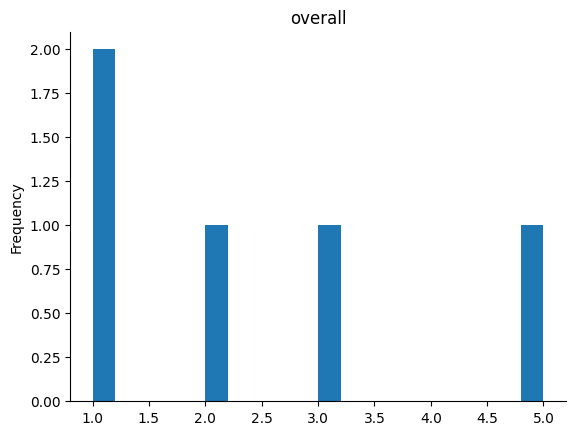

In [27]:
from matplotlib import pyplot as plt
_df_8['overall'].plot(kind='hist', bins=20, title='overall')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [16]:
#counting the number of missing values in the dataset
twitter_data.isnull().sum()

,0
reviewerID,0
asin,0
reviewerName,24909
helpful,0
reviewText,1071
overall,0
summary,16
unixReviewTime,0
reviewTime,0


In [18]:
df['reviewerName'] = df['reviewerName'].fillna('Anonymous')
df['reviewText'] = df['reviewText'].fillna('No review provided')
df['summary'] = df['summary'].fillna('No summary')



In [19]:
#counting the number of missing values in the dataset
twitter_data.isnull().sum()

,0
reviewerID,0
asin,0
reviewerName,24909
helpful,0
reviewText,0
overall,0
summary,0
unixReviewTime,0
reviewTime,0


In [20]:
df['reviewerName'] = df['reviewerName'].fillna('Anonymous')


In [21]:
print(df.isnull().sum())


reviewerID        0
asin              0
reviewerName      0
helpful           0
reviewText        0
overall           0
summary           0
unixReviewTime    0
reviewTime        0
dtype: int64


In [44]:
# Keep only rows with overall rating 1, 2, 4, or 5
df = df[df['overall'] != 3]

# Create binary sentiment target
df['sentiment'] = df['overall'].apply(lambda x: 1 if x >= 4 else 0)

In [45]:
#printing the first five rows of the dataframe
twitter_data.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,sentiment,sentiment2
0,AO94DHGC771SJ,0528881469,amazdnu,"[0, 0]",We got this GPS for my husband who is an (OTR)...,5.0,Gotta have GPS!,1370131200,"06 2, 2013",1,1
1,AMO214LNFCEI4,0528881469,Amazon Customer,"[12, 15]","I'm a professional OTR truck driver, and I bou...",1.0,Very Disappointed,1290643200,"11 25, 2010",0,0
3,A1H8PY3QHMQQA0,0528881469,"Dave M. Shaw ""mack dave""","[9, 10]","Not going to write a long review, even thought...",2.0,"Great grafics, POOR GPS",1290556800,"11 24, 2010",0,0
4,A24EV6RXELQZ63,0528881469,Wayne Smith,"[0, 0]",I've had mine for a year and here's what we go...,1.0,"Major issues, only excuses for support",1317254400,"09 29, 2011",0,0
5,A2JXAZZI9PHK9Z,0594451647,"Billy G. Noland ""Bill Noland""","[3, 3]",I am using this with a Nook HD+. It works as d...,5.0,HDMI Nook adapter cable,1388707200,"01 3, 2014",1,1


In [31]:
# Show first few rows including the new sentiment column
df[['overall', 'reviewText', 'sentiment']].head()


,overall,reviewText,sentiment
0,5.0,We got this GPS for my husband who is an (OTR)...,1
1,1.0,"I'm a professional OTR truck driver, and I bou...",0
3,2.0,"Not going to write a long review, even thought...",0
4,1.0,I've had mine for a year and here's what we go...,0
5,5.0,I am using this with a Nook HD+. It works as d...,1


from matplotlib import pyplot as plt
_df_29['overall'].plot(kind='hist', bins=20, title='overall')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_30['sentiment'].plot(kind='hist', bins=20, title='sentiment')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_31.groupby('reviewText').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_32.plot(kind='scatter', x='overall', y='sentiment', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_34['sentiment'].plot(kind='line', figsize=(8, 4), title='sentiment')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_35['reviewText'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_35, x='overall', y='reviewText', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_36['reviewText'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_36, x='sentiment', y='reviewText', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [49]:
print(df.columns)


Index(['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText',
       'overall', 'summary', 'unixReviewTime', 'reviewTime', 'sentiment',
       'sentiment2'],
      dtype='object')


In [36]:
twitter_data = df

In [48]:
#checking the distribution of target column
twitter_data['sentiment'].value_counts()

,count
sentiment,
1,1356067
0,190864


In [46]:
twitter_data['sentiment2'] = twitter_data['overall'].apply(lambda x: 1 if x >= 4 else (0 if x <= 2 else 2))


In [47]:
#checking the distribution of target column
twitter_data['sentiment2'].value_counts()

,count
sentiment2,
1,1356067
0,190864


In [52]:
port_stem = PorterStemmer()#reduce word to root word

In [53]:
def stemming(content):#content is each tweet in dataframe
  stemmed_content = re.sub('[^a-zA-Z]',' ',content)# ^ reomoves all non-alphabetic values
  stemmed_content = stemmed_content.lower()#convet uppercase to lowercase
  stemmed_content = stemmed_content.split()#split all word store in list
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  #words of stopwords are ignored and not particiate in stemming
  stemmed_content = ' '.join(stemmed_content)
  return stemmed_content

In [ ]:
twitter_data['stemmed_content'] = twitter_data['reviewText'].apply(stemming)
#stemmed_content is new column
#twitter_data['text] is taking text column for stemming function

In [ ]:
twitter_data.head()

In [ ]:
print(twitter_data['stemmed_content'])

In [ ]:

print(twitter_data['sentiment'])

In [ ]:
#separting the data and label
X = twitter_data['stemmed_content'].values
Y = twitter_data['sentiment'].values